## Stage 09 — Promoter Methylation vs. Expression

**Goal:** test whether promoter methylation of a PAM50 gene is associated with lower expression of that *same* gene. 

**Implementation:** for each gene calculate *Spearman-correlation* between its promoter CpGs and its log2 mRNA. 

- Spearman-correlation for rank-based data and robustness wrt variance and outliers
- A *negative* correlation indicates epigenetic *silencing* (more methylation → less expression).

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)


## Load data

`rna` data is without missing values. 

`meth` For correlation analysis the **globally KNN-imputed** methylation can be used. This ensures that the analysis has no missing values. There is no data-leakage because this stage is part of the descriptive EDA, and not used for modelling - there is no train/test split -> global imputation cannot leak. 

`cpg_gene` loads the table from 05b which links promoter CpG and gene for python usage.

The `assert` ensures that no missingvalues remain.

In [17]:
meth = pd.read_csv("../data/processed/meth_pam50_knn_imputed.csv", index_col=0)
rna = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
cpg_gene = pd.read_csv("../data/processed/cpg_gene_map.csv")

assert meth.isna().sum().sum() == 0, "Imputed methylation still contains NaNs."


## Align patients and keep valid CpG–gene pairs

`intersection` keeps only those patients which are present in *rna* and *meth*. Alignment across both omics layers per patient.

`cpg_gene` maps each promoter CpG to its PAM50 gene. Only those pairs are kept whose CpG and gene are both in the data.

In [18]:
patients = meth.index.intersection(rna.index)
meth = meth.loc[patients]
rna = rna.loc[patients]
print(f"Patients used: {len(patients)} | CpGs: {meth.shape[1]} | genes: {rna.shape[1]}")

cpg_gene = cpg_gene[cpg_gene["cpg"].isin(meth.columns) & cpg_gene["gene"].isin(rna.columns)]
print(f"CpG-gene pairs tested: {len(cpg_gene)}")


Patients used: 563 | CpGs: 527 | genes: 50
CpG-gene pairs tested: 527


## Benjamini–Hochberg correction for false discovery rate in multiple testing

As each of the hundreds of CpG-gene pairs is Spearman tested and approximately 5% false positives are expectable, correction of p-values to control FDR is necessary.  

Benjamini–Hochberg correction controls the *false discovery rate* and returns a *q-value* per test. 

- `argsort(p)` sorts p-values 
- `ranked` scale each by n/rank (BH)
- `q` enforce monotonicity from the back s.t. smaller p-values are mapped to small q-values
- `clip` to [0,1] to retain probabilities

In [19]:
def bh_qvalues(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]  # enforce monotonicity
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


## Spearman correlation for each CpG

- *Spearman* (rank-based correlation) is used because the relationship between methylation and expression does not need to be linear and rank correlation is robust to outliers. 

- compute rho + p-value per pair
- `cpg_corr["q_value"]` add BH q-values
- `cpg_corr.sort_values("spearman_rho")` sort st the most negative (strongest silencing) come first
- `csv` contains one row per CpG-gene combination with probe info, correlation, p- and q-values

In [20]:
rows = []
for _, (cpg, gene) in cpg_gene[["cpg", "gene"]].iterrows():
    rho, pval = spearmanr(meth[cpg], rna[gene])
    rows.append({"cpg": cpg, "gene": gene, "spearman_rho": rho, "p_value": pval})

cpg_corr = pd.DataFrame(rows)
cpg_corr["q_value"] = bh_qvalues(cpg_corr["p_value"])
cpg_corr = cpg_corr.sort_values("spearman_rho")
cpg_corr.to_csv("../results/tables/cpg_expression_spearman.csv", index=False)

cpg_corr.to_csv("../results/tables/cpg_expression_spearman.csv", index=False)
print(f"Saved cpg_expression_spearman.csv ({len(cpg_corr)} rows)")

Saved cpg_expression_spearman.csv (527 rows)


## Per-gene summary

A gene can have several promoter CpGs, so the per-CpG results are aggregated to one row per gene.

- `cpg_corr.groupby("gene")` group all CpGs by their gene
- `n_cpgs` number of CpGs per gene 
- `mean_rho`mean correlation per gene
- `min_rho` most-negative single CpG per gene



- `cpg_corr.sort_values("mean_rho")` sort st genes are ranked by silencing strength (most negative first)
- `csv` contains one row per gene with the aggregated stats

In [21]:
grp = cpg_corr.groupby("gene")
gene_corr = pd.DataFrame({
    "n_cpgs": grp.size(),
    "mean_rho": grp["spearman_rho"].mean(),
    "min_rho": grp["spearman_rho"].min(),
})

min_idx = grp["spearman_rho"].idxmin().reindex(gene_corr.index)
gene_corr["min_rho_cpg"] = cpg_corr.loc[min_idx, "cpg"].values
gene_corr["min_rho_qvalue"] = cpg_corr.loc[min_idx, "q_value"].values
gene_corr = gene_corr.sort_values("mean_rho")
gene_corr.index.name = "gene"
gene_corr.to_csv("../results/tables/gene_methylation_expression_correlation_summary.csv")

gene_corr.to_csv("../results/tables/gene_methylation_expression_correlation_summary.csv")
print(f"Saved gene summary ({len(gene_corr)} genes)")

Saved gene summary (49 genes)


## Strongest-silencing gene

- identify the gene with the most negative mean rho (highest silencing)
- necessary for later analysis in survival script (stage 10) to define methylation stratification. 

In [22]:
top_gene = gene_corr.index[0]
top_cpg = gene_corr.loc[top_gene, "min_rho_cpg"]
print(f"Strongest silencing gene: {top_gene} "
      f"(mean rho={gene_corr.loc[top_gene, 'mean_rho']:.2f}, "
      f"min rho={gene_corr.loc[top_gene, 'min_rho']:.2f} at {top_cpg})")


Strongest silencing gene: ESR1 (mean rho=-0.42, min rho=-0.59 at cg15543523)


## Figure 1 — mean Spearman rho per PAM50 gene

Horizontal bar for each gene sorted by silencing value 
- red = negative (silencing)
- blue = positive.

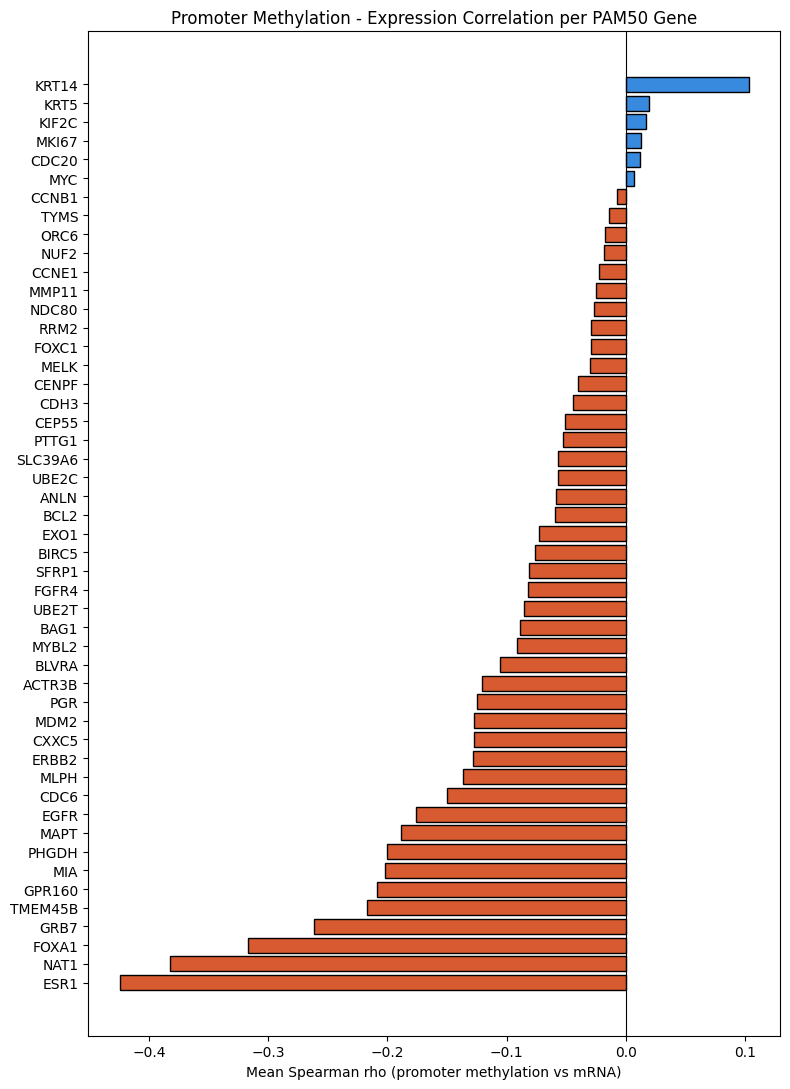

In [23]:
colors = ["#D85A30" if r < 0 else "#378ADD" for r in gene_corr["mean_rho"]]
plt.figure(figsize=(8, 11))
plt.barh(gene_corr.index, gene_corr["mean_rho"], color=colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mean Spearman rho (promoter methylation vs mRNA)")
plt.title("Promoter Methylation - Expression Correlation per PAM50 Gene")
plt.tight_layout()
plt.savefig("../results/figures/methylation_expression_correlation_by_gene.png", dpi=300)
plt.show()


## Figure 2 — scatter plot 

Methylation beta vs. log2 expression for the strongest silencing cpg

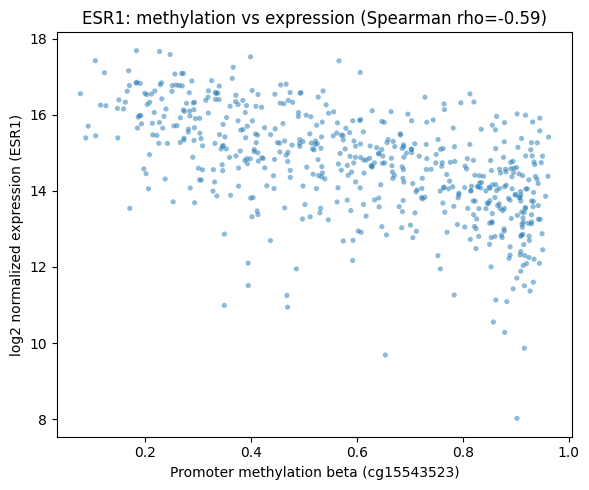

Saved correlation tables and figures to ../results/.


In [24]:
rho, _ = spearmanr(meth[top_cpg], rna[top_gene])
plt.figure(figsize=(6, 5))
plt.scatter(meth[top_cpg], rna[top_gene], s=14, alpha=0.5, edgecolor="none")
plt.xlabel(f"Promoter methylation beta ({top_cpg})")
plt.ylabel(f"log2 normalized expression ({top_gene})")
plt.title(f"{top_gene}: methylation vs expression (Spearman rho={rho:.2f})")
plt.tight_layout()
plt.savefig("../results/figures/top_silencing_gene_scatter.png", dpi=300)
plt.show()

print("Saved correlation tables and figures to ../results/.")
